In [2]:
import arviz as az
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import bambi as bmb
import pymc as pm
import preliz as pz

In [3]:
SIZE = 117
data = pd.DataFrame(
    {
        "y": np.random.normal(size=SIZE),
        "x": np.random.normal(size=SIZE),
        "z": np.random.normal(size=SIZE),
        "g": ["Group A", "Group B", "Group C"] * 39,
    }
)
data.head()

,y,x,z,g
0,0.881698,-0.096896,1.103961,Group A
1,-0.464981,0.104999,-1.276135,Group B
2,0.103418,0.447919,-0.111136,Group C
3,-0.117624,-0.695319,0.479268,Group A
4,0.521611,0.072862,0.378725,Group B


In [4]:
with pm.Model() as lm:
    Intercept = pm.Normal("Intercept", 0, 1)
    x = pm.Normal("x", 0, 1)
    y_sigma = pm.HalfNormal("sigma", 1)
    y_mean = Intercept + x * data["x"]
    y = pm.Normal("y", y_mean, y_sigma, observed=data['y'])
    


In [5]:
lm

Intercept ~ Normal(0, 1)
        x ~ Normal(0, 1)
    sigma ~ HalfNormal(0, 1)
        y ~ Normal(f(Intercept, x), sigma)

In [6]:
a_model = bmb.Model('y ~ x', data)
a_model

       Formula: y ~ x
        Family: gaussian
          Link: mu = identity
  Observations: 117
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: -0.1661, sigma: 2.3591)
            x ~ Normal(mu: 0.0, sigma: 2.361)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.9389)

In [7]:
idata_model = a_model.fit()
idata_model

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, Intercept, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Sampling: [Intercept, x, y_sigma]


array([<Axes: title={'center': 'Intercept'}>,
       <Axes: title={'center': 'y_sigma'}>, <Axes: title={'center': 'x'}>],
      dtype=object)

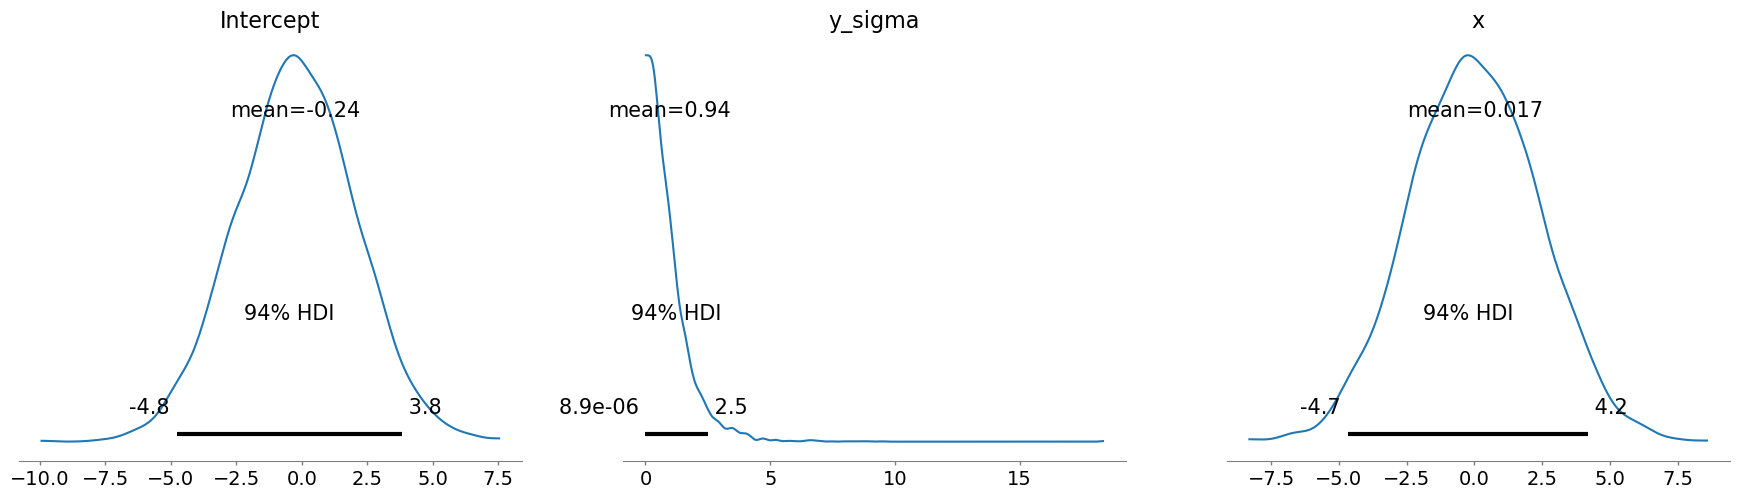

In [8]:
a_model.plot_priors()

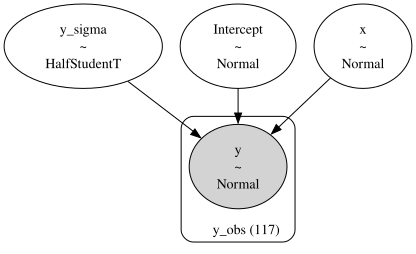

In [9]:
a_model.graph()

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: xlabel='x', ylabel='y'>], dtype=object))

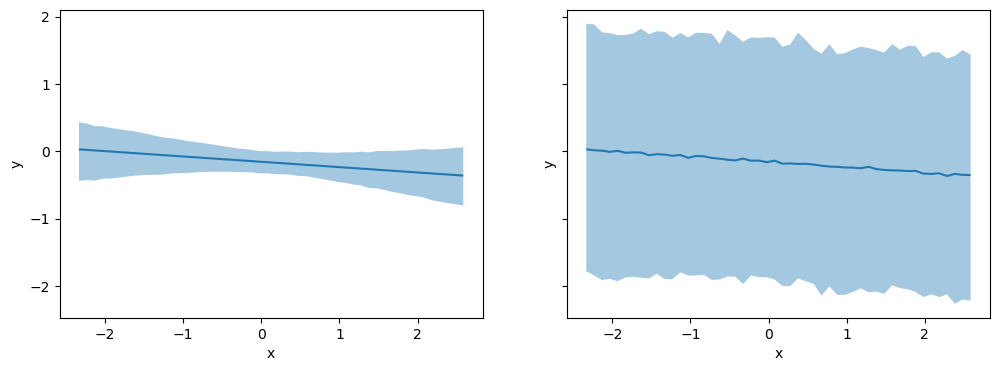

In [10]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(a_model, idata_model, "x", ax=axes[0])
bmb.interpret.plot_predictions(a_model, idata_model, "x", pps=True, ax=axes[1])

In [11]:
priors = {
    "x": bmb.Prior("HalfNormal", sigma=3),
    "sigma": bmb.Prior("Gamma", mu=1, sigma=2)
}
a_model_wcp = bmb.Model('y ~ x', data, priors=priors)

In [12]:
a_model_wcp

       Formula: y ~ x
        Family: gaussian
          Link: mu = identity
  Observations: 117
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: -0.1661, sigma: 2.3472)
            x ~ HalfNormal(sigma: 3.0)
        
        Auxiliary parameters
            sigma ~ Gamma(mu: 1.0, sigma: 2.0)

In [13]:
idata_wcp_model = a_model_wcp.fit()
idata_wcp_model

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, Intercept, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

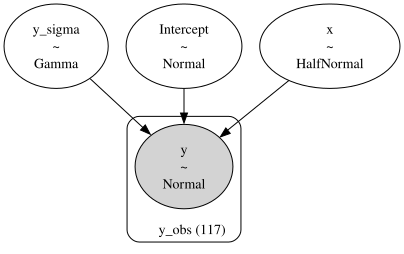

In [14]:
a_model_wcp.graph()

Sampling: [Intercept, x, y_sigma]


array([<Axes: title={'center': 'Intercept'}>,
       <Axes: title={'center': 'y_sigma'}>, <Axes: title={'center': 'x'}>],
      dtype=object)

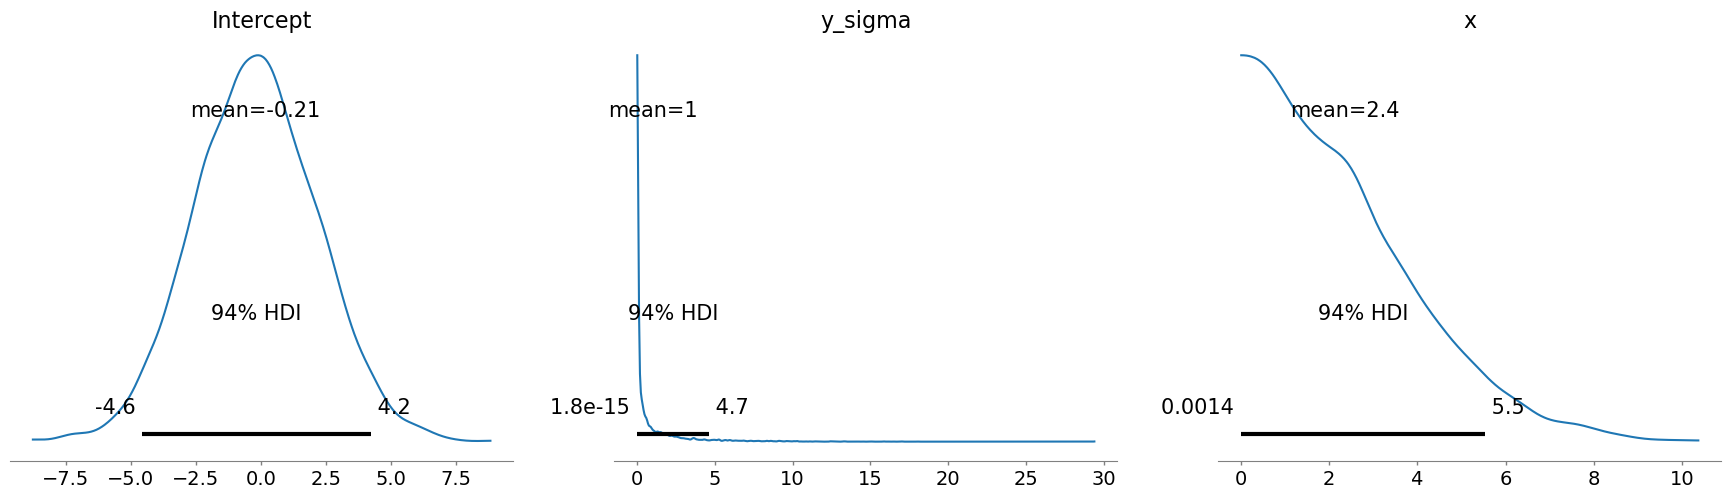

In [15]:
a_model_wcp.plot_priors()

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: xlabel='x', ylabel='y'>], dtype=object))

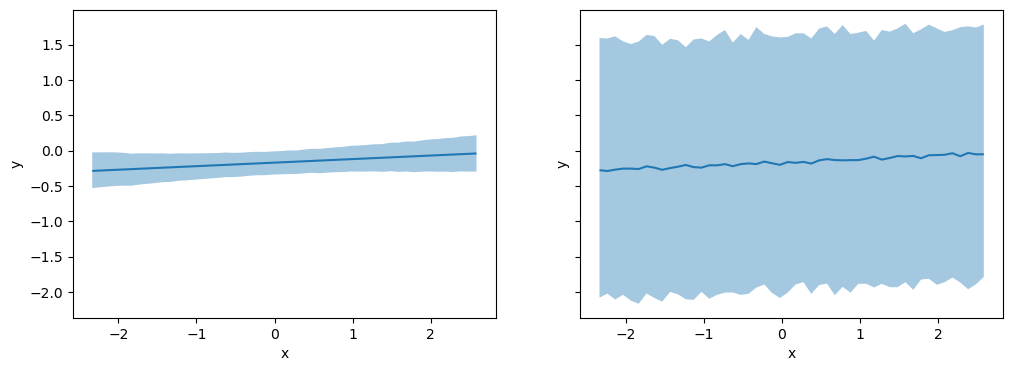

In [16]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(a_model_wcp, idata_wcp_model, "x", ax=axes[0])
bmb.interpret.plot_predictions(a_model_wcp, idata_wcp_model, "x", pps=True, ax=axes[1])

In [17]:
no_intercept_model = bmb.Model("y ~ 0 + x", data)
no_intercept_model

       Formula: y ~ 0 + x
        Family: gaussian
          Link: mu = identity
  Observations: 117
        Priors: 
    target = mu
        Common-level effects
            x ~ Normal(mu: 0.0, sigma: 2.361)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.9389)

In [18]:
no_intercept_model = bmb.Model('y ~ -1 + x', data)
no_intercept_model

       Formula: y ~ -1 + x
        Family: gaussian
          Link: mu = identity
  Observations: 117
        Priors: 
    target = mu
        Common-level effects
            x ~ Normal(mu: 0.0, sigma: 2.361)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.9389)

In [19]:
idata_no_int_model =  no_intercept_model.fit()
idata_no_int_model

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Sampling: [x, y_sigma]


array([<Axes: title={'center': 'y_sigma'}>, <Axes: title={'center': 'x'}>],
      dtype=object)

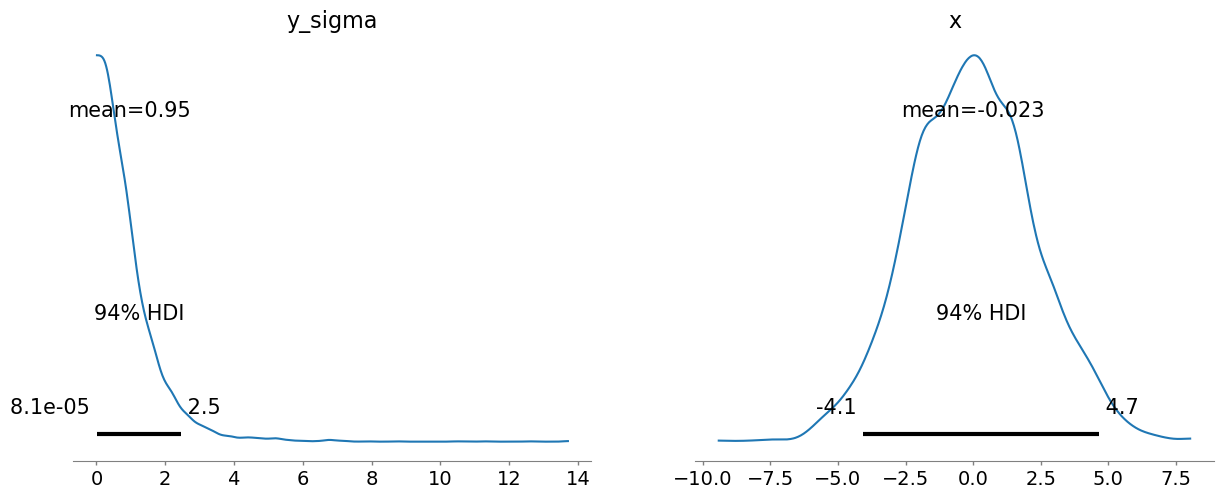

In [20]:
no_intercept_model.plot_priors()

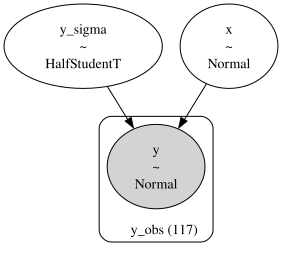

In [21]:
no_intercept_model.graph()

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: xlabel='x', ylabel='y'>], dtype=object))

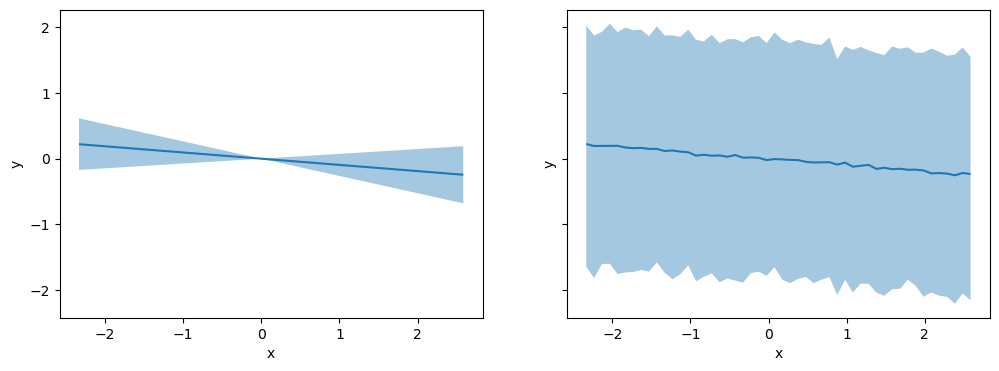

In [22]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(no_intercept_model, idata_no_int_model, "x", ax=axes[0])
bmb.interpret.plot_predictions(no_intercept_model, idata_no_int_model, 'x', pps=True, ax=axes[1])

In [23]:
model_2 = bmb.Model('y ~ x + z', data)
model_2

       Formula: y ~ x + z
        Family: gaussian
          Link: mu = identity
  Observations: 117
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: -0.1661, sigma: 2.3669)
            x ~ Normal(mu: 0.0, sigma: 2.361)
            z ~ Normal(mu: 0.0, sigma: 2.2943)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.9389)

In [26]:
idata_model_2 = model_2.fit()
idata_model_2

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, Intercept, x, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

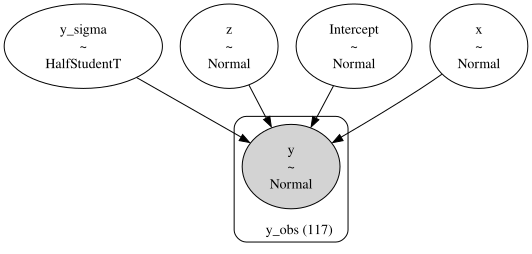

In [27]:
model_2.graph()

Sampling: [Intercept, x, y_sigma, z]


array([<Axes: title={'center': 'Intercept'}>,
       <Axes: title={'center': 'y_sigma'}>, <Axes: title={'center': 'x'}>,
       <Axes: title={'center': 'z'}>], dtype=object)

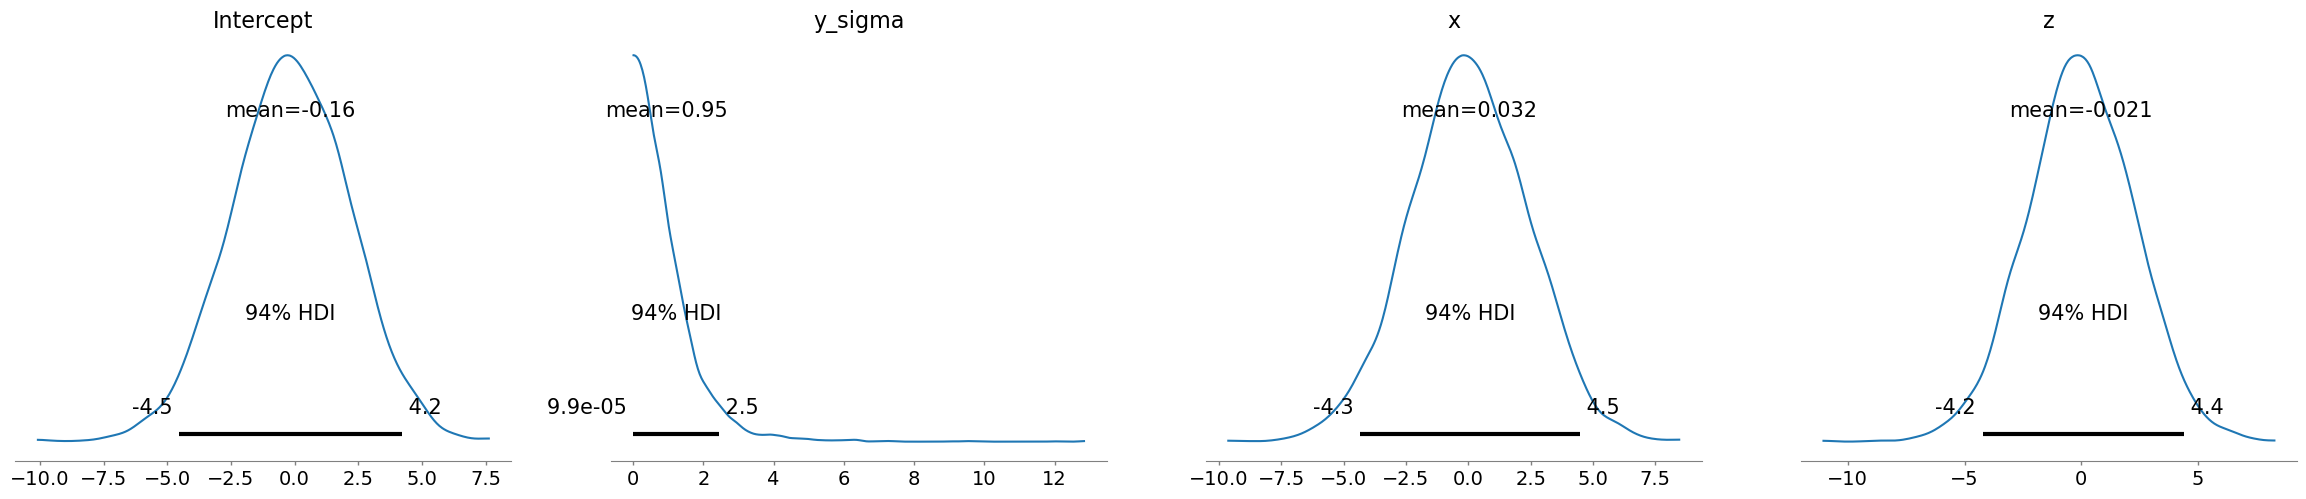

In [28]:
model_2.plot_priors()

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: xlabel='x', ylabel='y'>], dtype=object))

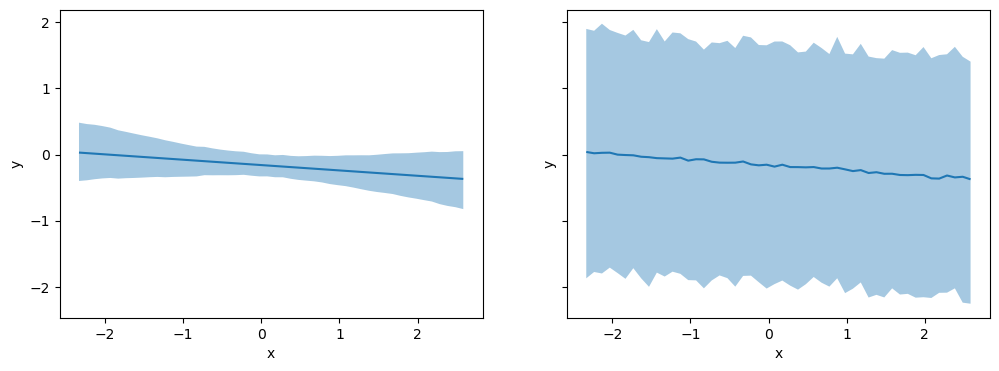

In [29]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(model_2, idata_model_2, "x", ax=axes[0])
bmb.interpret.plot_predictions(model_2, idata_model_2, 'x', pps=True, ax=axes[1])

In [30]:
model_h = bmb.Model('y ~ x + z + (x | g)', data)
model_h

       Formula: y ~ x + z + (x | g)
        Family: gaussian
          Link: mu = identity
  Observations: 117
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: -0.1661, sigma: 2.3669)
            x ~ Normal(mu: 0.0, sigma: 2.361)
            z ~ Normal(mu: 0.0, sigma: 2.2943)
        
        Group-level effects
            1|g ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.3669))
            x|g ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.361))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.9389)

In [31]:
idata_model_h = model_h.fit()
idata_model_h

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, Intercept, x, z, 1|g_sigma, 1|g_offset, x|g_sigma, x|g_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.
There were 47 divergences after tuning. Increase `target_accept` or reparameterize.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

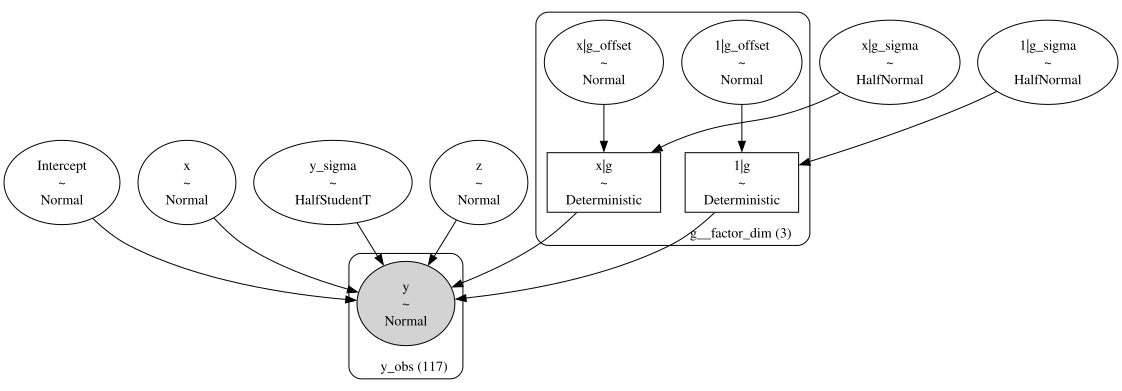

In [32]:
model_h.graph()

Sampling: [1|g_sigma, Intercept, x, x|g_sigma, y_sigma, z]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'y_sigma'}>,
        <Axes: title={'center': 'x'}>],
       [<Axes: title={'center': 'z'}>,
        <Axes: title={'center': '1|g_sigma'}>,
        <Axes: title={'center': 'x|g_sigma'}>]], dtype=object)

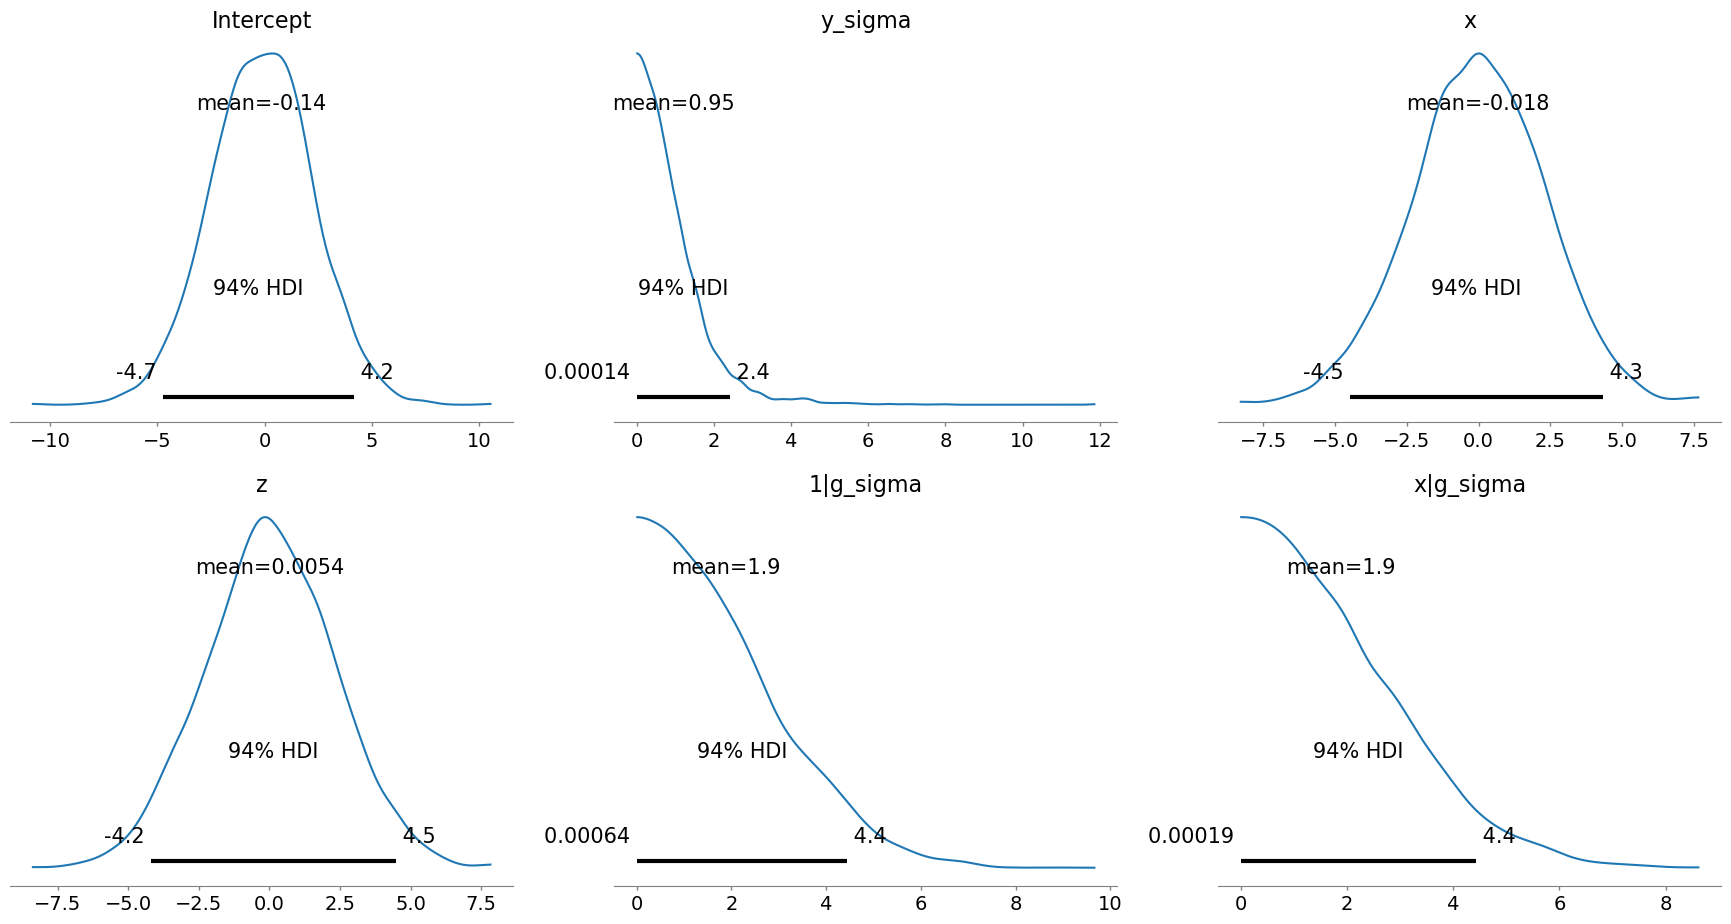

In [33]:
model_h.plot_priors()

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: xlabel='x', ylabel='y'>], dtype=object))

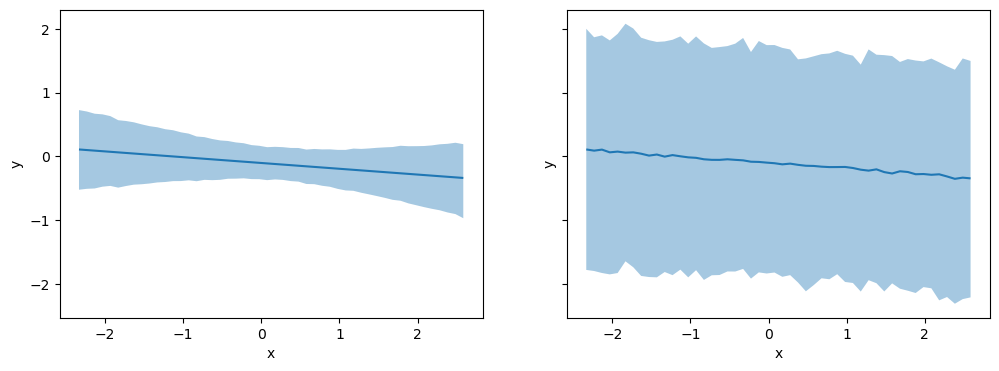

In [34]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(model_h, idata_model_h, "x", ax=axes[0])
bmb.interpret.plot_predictions(model_h, idata_model_h, 'x', pps=True, ax=axes[1])

## 6.2

In [35]:
bikes = pd.read_csv('data/bikes.csv')
bikes

,rented,hour,temperature,humidity,windspeed,weekday
0,16,0,3.28,0.81,0.0000,6
1,3,5,-0.48,0.47,0.2836,1
2,115,9,2.34,0.37,0.3284,3
3,73,13,1.40,0.37,0.2836,5
4,82,15,2.34,0.35,0.3582,0
...,...,...,...,...,...,...
343,90,9,4.22,0.48,0.3881,6
344,135,12,5.16,0.56,0.0896,1
345,13,15,4.22,0.87,0.3582,3
346,271,17,3.28,0.60,0.1343,5


In [36]:
model_t = bmb.Model('rented ~ temperature', bikes, family='negativebinomial')
idata_t = model_t.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rented_alpha, Intercept, temperature]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [37]:
display(model_t)
idata_t

       Formula: rented ~ temperature
        Family: negativebinomial
          Link: mu = log
  Observations: 348
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 4.9184)
            temperature ~ Normal(mu: 0.0, sigma: 0.2741)
        
        Auxiliary parameters
            alpha ~ HalfCauchy(beta: 1.0)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

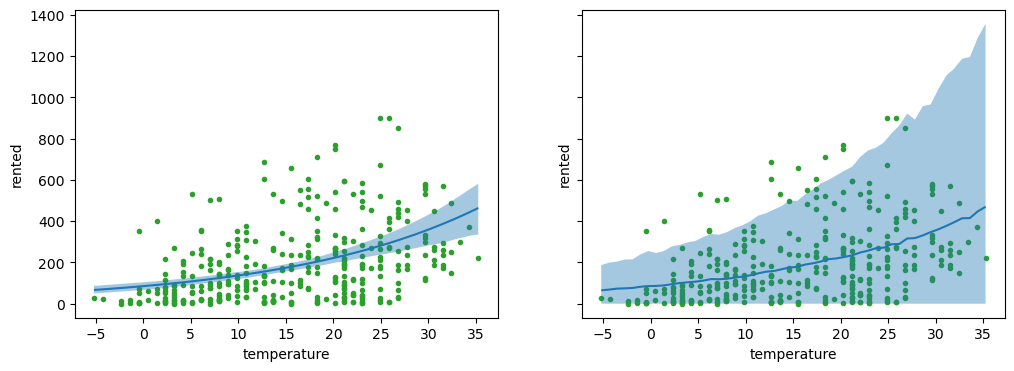

In [40]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
bmb.interpret.plot_predictions(model_t, idata_t, 'temperature', ax=axes[0])
bmb.interpret.plot_predictions(model_t, idata_t, 'temperature', pps=True, ax=axes[1])
axes[0].plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
axes[1].plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)


In [41]:
model_th = bmb.Model('rented ~ temperature + humidity', bikes, family='negativebinomial')
idata_th = model_th.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rented_alpha, Intercept, temperature, humidity]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


/opt/conda/envs/bap3/lib/python3.11/site-packages/bambi/interpret/utils.py:383: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_string_dtype(x) or is_categorical_dtype(x):


(<Figure size 1200x800 with 6 Axes>,
 array([[<Axes: title={'center': 'humidity = 0.18'}, xlabel='temperature', ylabel='rented'>,
         <Axes: title={'center': 'humidity = 0.5'}, xlabel='temperature', ylabel='rented'>,
         <Axes: title={'center': 'humidity = 0.635'}, xlabel='temperature', ylabel='rented'>],
        [<Axes: title={'center': 'humidity = 0.78'}, xlabel='temperature', ylabel='rented'>,
         <Axes: title={'center': 'humidity = 1.0'}, xlabel='temperature', ylabel='rented'>,
         <Axes: xlabel='temperature', ylabel='rented'>]], dtype=object))

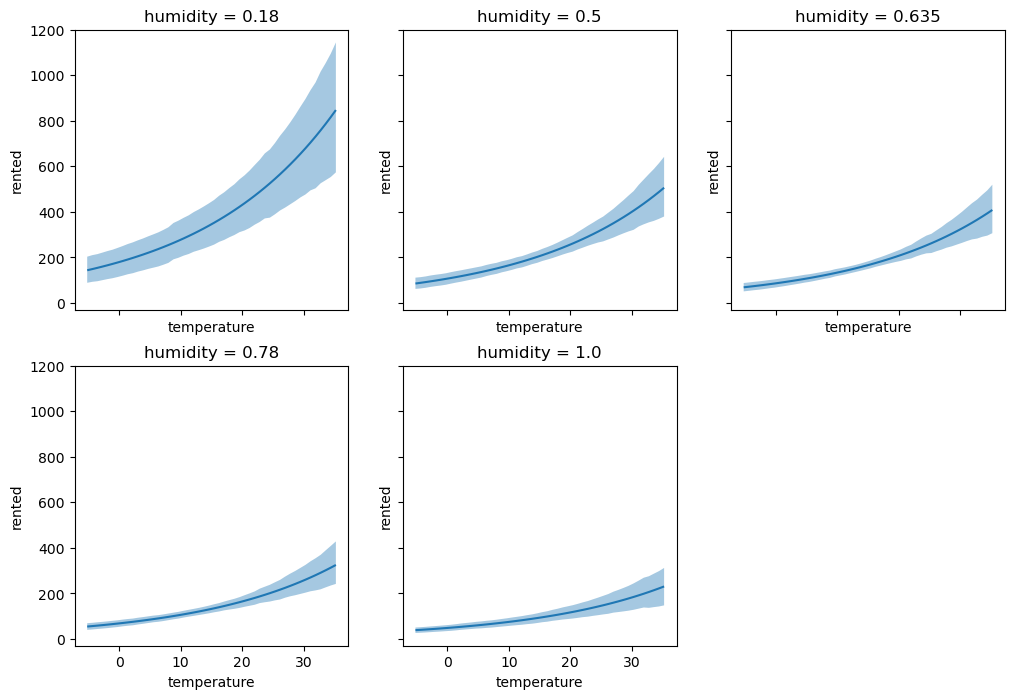

In [46]:
x
bmb.interpret.plot_predictions(model_th, idata_th, ['temperature', 'humidity'], 
                               subplot_kwargs={'group':None, 'panel':'humidity'},
                               fig_kwargs={"sharey":True, "sharex":True, "figsize":(12, 8)})

## 6.3